
# Election Bloc Change Prediction Project  
## Notebook 03 — Exploratory Analysis and Baseline Evaluation

### Purpose

This notebook addresses the central methodological concern raised during project review:

> Locality-level voting patterns are highly stable. A simple forecast based on the previous election may outperform a model based on demographic and socioeconomic variables.

The notebook therefore evaluates how difficult the revised prediction task really is before any advanced model is trained.

### Main tasks

1. Load the transition panel produced by Notebook 02.
2. Attach locality-type information.
3. Keep the Knesset 25 transition locked as the final test set.
4. Measure voting stability in the development data.
5. Evaluate the previous-election persistence baseline.
6. Compare persistence with several simple baselines:
   - global mean voting level
   - locality-type mean voting level
   - global historical swing
   - locality-type historical swing
7. Report results by bloc and separately for Arab/non-Jewish and non-Arab localities.
8. Identify where meaningful change exists and where later modeling may add value.

### Experimental split

| Role | Transition |
|---|---|
| Training for fitted baselines | K21→K22 and K22→K23 |
| Validation | K23→K24 |
| Locked final test | K24→K25 |

The final test transition is loaded only to verify its presence and is excluded from all analysis in this notebook.

### Main outputs

- `data/interim/election_transition_panel_with_locality_type.csv`
- `reports/tables/stability_by_transition_and_bloc.csv`
- `reports/tables/stability_by_group_and_bloc.csv`
- `reports/tables/baseline_comparison_validation.csv`
- `reports/tables/baseline_comparison_by_bloc_validation.csv`
- `reports/tables/baseline_comparison_by_group_validation.csv`
- `reports/tables/largest_validation_changes.csv`
- `reports/figures/baseline_validation_comparison.png`
- `reports/summaries/notebook_03_summary.json`


## 1. Imports and repository setup

In [1]:

from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 99

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

TRAIN_TRANSITIONS = [
    "K21_to_K22",
    "K22_to_K23",
]

VALIDATION_TRANSITION = "K23_to_K24"
FINAL_TEST_TRANSITION = "K24_to_K25"


In [2]:

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

DEFAULT_REPO_DIR = Path(
    "/content/Election_Bloc_Prediction_Project"
)


def locate_repository():
    """Locate the project repository or clone it in a fresh Colab runtime."""
    candidates = []

    explicit_root = os.getenv("ELECTION_PROJECT_ROOT")
    if explicit_root:
        candidates.append(Path(explicit_root).expanduser())

    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    candidates.extend([
        DEFAULT_REPO_DIR,
        Path("/content/Election_Bloc_Change_Project"),
    ])

    checked = set()

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate in checked:
            continue

        checked.add(candidate)

        if (candidate / "data" / "raw").exists():
            return candidate

    if Path("/content").exists():
        if DEFAULT_REPO_DIR.exists():
            shutil.rmtree(DEFAULT_REPO_DIR)

        print("Repository not found locally.")
        print("Cloning the project repository...")

        result = subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(DEFAULT_REPO_DIR),
            ],
            text=True,
            capture_output=True,
        )

        if result.stdout:
            print(result.stdout)

        if result.returncode != 0:
            if result.stderr:
                print(result.stderr)

            raise RuntimeError(
                "Git clone failed. Review the Git output above."
            )

        return DEFAULT_REPO_DIR

    checked_text = "\n".join(
        f"- {path}" for path in checked
    )

    raise FileNotFoundError(
        "Could not locate the project repository.\n"
        f"Checked:\n{checked_text}"
    )


def synchronize_if_missing(repo_root, required_paths):
    """Pull the latest main branch when a required file is absent locally."""
    missing = [
        path
        for path in required_paths
        if not path.exists()
    ]

    if not missing:
        return

    if not (repo_root / ".git").exists():
        return

    print("Some required files are missing locally.")
    print("Synchronizing with GitHub...")

    result = subprocess.run(
        [
            "git",
            "-C",
            str(repo_root),
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        text=True,
        capture_output=True,
    )

    if result.stdout:
        print(result.stdout)

    if result.returncode != 0:
        if result.stderr:
            print(result.stderr)

        raise RuntimeError(
            "Git pull failed. Resolve local repository conflicts "
            "or restart the runtime and run the notebook again."
        )


REPO_ROOT = locate_repository()

RAW_DIR = REPO_ROOT / "data" / "raw"
INTERIM_DIR = REPO_ROOT / "data" / "interim"

REPORTS_DIR = REPO_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
SUMMARIES_DIR = REPORTS_DIR / "summaries"

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

TRANSITION_PANEL_PATH = (
    INTERIM_DIR / "election_transition_panel.csv"
)

LOCALITY_TYPES_PATH = (
    RAW_DIR / "Locality_Types.xlsx"
)

NOTEBOOK_02_SUMMARY_PATH = (
    SUMMARIES_DIR / "notebook_02_summary.json"
)

synchronize_if_missing(
    REPO_ROOT,
    [
        TRANSITION_PANEL_PATH,
        LOCALITY_TYPES_PATH,
        NOTEBOOK_02_SUMMARY_PATH,
    ],
)

print("Repository root:", REPO_ROOT)
print("Transition panel:", TRANSITION_PANEL_PATH)
print("Locality types:", LOCALITY_TYPES_PATH)


Repository not found locally.
Cloning the project repository...
Repository root: /content/Election_Bloc_Prediction_Project
Transition panel: /content/Election_Bloc_Prediction_Project/data/interim/election_transition_panel.csv
Locality types: /content/Election_Bloc_Prediction_Project/data/raw/Locality_Types.xlsx


## 2. Load and validate Notebook 02 outputs

In [3]:

required_files = [
    TRANSITION_PANEL_PATH,
    LOCALITY_TYPES_PATH,
    NOTEBOOK_02_SUMMARY_PATH,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required files are missing:\n"
        + "\n".join(str(path) for path in missing_files)
    )

transition_panel = pd.read_csv(
    TRANSITION_PANEL_PATH,
    dtype={"locality_symbol": "string"},
)

with NOTEBOOK_02_SUMMARY_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    notebook_02_summary = json.load(file)

expected_rows = notebook_02_summary["rows_created"]

if len(transition_panel) != expected_rows:
    raise ValueError(
        "Transition-panel row count differs from Notebook 02 summary. "
        f"Expected {expected_rows}, found {len(transition_panel)}."
    )

duplicate_count = int(
    transition_panel.duplicated(
        ["locality_symbol", "transition_id"]
    ).sum()
)

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicated locality-transition rows."
    )

print("Rows loaded:", len(transition_panel))
print(
    "Unique localities:",
    transition_panel["locality_symbol"].nunique(),
)
print(
    "Transitions:",
    transition_panel["transition_id"].value_counts().to_dict(),
)


Rows loaded: 4851
Unique localities: 1217
Transitions: {'K22_to_K23': 1214, 'K24_to_K25': 1213, 'K21_to_K22': 1212, 'K23_to_K24': 1212}



## 3. Attach locality types

Locality type is needed for two reasons:

1. To test how much voting can be predicted from broad locality classification alone.
2. To report performance separately for Arab/non-Jewish and non-Arab localities.

The locality symbol is used only as a merge key and never as a predictive feature.


In [4]:

def clean_column_name(column):
    return str(column).replace("\ufeff", "").strip()


def numeric_series(series):
    cleaned = (
        series.astype("string")
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    return pd.to_numeric(
        cleaned,
        errors="coerce",
    )


def normalize_locality_symbol(series):
    return (
        numeric_series(series)
        .astype("Int64")
        .astype("string")
    )


def first_existing_column(
    df,
    candidates,
    required=True,
):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate

    if required:
        raise KeyError(
            f"None of the expected columns were found: {candidates}"
        )

    return None


locality_types_raw = pd.read_excel(
    LOCALITY_TYPES_PATH,
)

locality_types_raw.columns = [
    clean_column_name(column)
    for column in locality_types_raw.columns
]

symbol_column = first_existing_column(
    locality_types_raw,
    [
        "סמל יישוב",
        "סמל ישוב",
        "locality_symbol",
    ],
)

type_column = first_existing_column(
    locality_types_raw,
    [
        "type",
        "Type",
        "locality_type",
    ],
)

hebrew_type_column = first_existing_column(
    locality_types_raw,
    [
        "סוג יישוב",
        "סוג ישוב",
    ],
    required=False,
)

locality_types = pd.DataFrame({
    "locality_symbol": normalize_locality_symbol(
        locality_types_raw[symbol_column]
    ),
    "locality_type": (
        locality_types_raw[type_column]
        .astype("string")
        .str.strip()
    ),
})

if hebrew_type_column is not None:
    locality_types["locality_type_hebrew"] = (
        locality_types_raw[hebrew_type_column]
        .astype("string")
        .str.strip()
    )

locality_types = locality_types.dropna(
    subset=["locality_symbol"]
).copy()

conflicting_types = (
    locality_types.groupby(
        "locality_symbol"
    )["locality_type"]
    .nunique(dropna=True)
)

conflicting_types = conflicting_types[
    conflicting_types > 1
]

if not conflicting_types.empty:
    raise ValueError(
        "Some locality symbols have conflicting locality types:\n"
        + conflicting_types.to_string()
    )

locality_types = locality_types.drop_duplicates(
    subset=["locality_symbol"],
    keep="first",
)

locality_types.head()


,locality_symbol,locality_type,locality_type_hebrew
0,3000,Cities,"יישובים יהודיים 500,000 תושבים ומעלה"
1,70,Cities,"יישובים יהודיים 499,999-200,000 תושבים"
2,9000,Cities,"יישובים יהודיים 499,999-200,000 תושבים"
3,6100,Cities,"יישובים יהודיים 499,999-200,000 תושבים"
4,4000,Cities,"יישובים יהודיים 499,999-200,000 תושבים"


In [5]:

panel_with_type = transition_panel.merge(
    locality_types,
    on="locality_symbol",
    how="left",
    validate="many_to_one",
    indicator=True,
)

locality_type_merge_audit = pd.DataFrame({
    "merge_status": panel_with_type["_merge"]
    .value_counts()
    .index.astype(str),
    "rows": panel_with_type["_merge"]
    .value_counts()
    .values,
})

missing_type_rows = int(
    panel_with_type["locality_type"].isna().sum()
)

panel_with_type["locality_type"] = (
    panel_with_type["locality_type"]
    .fillna("Unknown")
)

panel_with_type[
    "is_arab_non_jewish"
] = panel_with_type[
    "locality_type"
].eq("Arab/Non-Jewish")

panel_with_type[
    "analysis_group"
] = np.where(
    panel_with_type["is_arab_non_jewish"],
    "Arab/Non-Jewish",
    "Non-Arab",
)

panel_with_type = panel_with_type.drop(
    columns="_merge"
)

print("Rows without a matched locality type:", missing_type_rows)
panel_with_type["locality_type"].value_counts(dropna=False)


Rows without a matched locality type: 15


,count
locality_type,
Moshavim,1801
Kibbutzim,1053
other,890
Cities,688
Arab/Non-Jewish,404
Unknown,15



## 4. Lock the final test transition

The K24→K25 transition is preserved for the final evaluation notebook.

No stability statistics, model comparisons, subgroup comparisons or anomaly inspection in this notebook use the final test rows.


In [6]:

train_data = panel_with_type.loc[
    panel_with_type["transition_id"].isin(
        TRAIN_TRANSITIONS
    )
].copy()

validation_data = panel_with_type.loc[
    panel_with_type["transition_id"].eq(
        VALIDATION_TRANSITION
    )
].copy()

final_test_data = panel_with_type.loc[
    panel_with_type["transition_id"].eq(
        FINAL_TEST_TRANSITION
    )
].copy()

development_data = pd.concat(
    [
        train_data,
        validation_data,
    ],
    ignore_index=True,
)

expected_total = (
    len(train_data)
    + len(validation_data)
    + len(final_test_data)
)

if expected_total != len(panel_with_type):
    raise ValueError(
        "Some transition rows were not assigned to train, "
        "validation or final test."
    )

split_summary = pd.DataFrame([
    {
        "split": "train",
        "transitions": ", ".join(TRAIN_TRANSITIONS),
        "rows": len(train_data),
        "used_in_this_notebook": True,
    },
    {
        "split": "validation",
        "transitions": VALIDATION_TRANSITION,
        "rows": len(validation_data),
        "used_in_this_notebook": True,
    },
    {
        "split": "final_test",
        "transitions": FINAL_TEST_TRANSITION,
        "rows": len(final_test_data),
        "used_in_this_notebook": False,
    },
])

split_summary


,split,transitions,rows,used_in_this_notebook
0,train,"K21_to_K22, K22_to_K23",2426,True
1,validation,K23_to_K24,1212,True
2,final_test,K24_to_K25,1213,False



## 5. Measure voting stability in the development period

The following statistics are calculated only for K21→K22, K22→K23 and K23→K24:

- correlation between previous and current bloc share
- mean absolute change
- median absolute change
- mean signed change
- share of locality transitions changing by at most 1, 2 or 5 percentage points


In [7]:

def safe_correlation(x, y):
    x = pd.Series(x)
    y = pd.Series(y)

    valid = x.notna() & y.notna()

    if valid.sum() < 2:
        return np.nan

    if (
        x.loc[valid].nunique() < 2
        or y.loc[valid].nunique() < 2
    ):
        return np.nan

    return float(
        x.loc[valid].corr(
            y.loc[valid]
        )
    )


def calculate_stability_rows(
    data,
    grouping_columns,
):
    rows = []

    grouped = data.groupby(
        grouping_columns,
        dropna=False,
        observed=False,
    )

    for group_key, group in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_values = dict(
            zip(
                grouping_columns,
                group_key,
            )
        )

        for bloc in MODELED_BLOCS:
            previous = group[
                f"previous_{bloc}_pct"
            ]

            current = group[
                f"current_{bloc}_pct"
            ]

            delta = (
                current
                - previous
            )

            absolute_delta = delta.abs()

            rows.append({
                **group_values,
                "bloc": bloc,
                "rows": len(group),
                "previous_current_correlation": (
                    safe_correlation(
                        previous,
                        current,
                    )
                ),
                "mean_signed_change_pct_points": (
                    float(delta.mean())
                ),
                "mean_absolute_change_pct_points": (
                    float(absolute_delta.mean())
                ),
                "median_absolute_change_pct_points": (
                    float(absolute_delta.median())
                ),
                "pct_within_1_point": float(
                    absolute_delta.le(1).mean() * 100
                ),
                "pct_within_2_points": float(
                    absolute_delta.le(2).mean() * 100
                ),
                "pct_within_5_points": float(
                    absolute_delta.le(5).mean() * 100
                ),
            })

    return pd.DataFrame(rows)


stability_by_transition_and_bloc = (
    calculate_stability_rows(
        development_data,
        ["transition_id"],
    )
)

stability_by_group_and_bloc = (
    calculate_stability_rows(
        development_data,
        ["analysis_group"],
    )
)

stability_by_transition_and_bloc


,transition_id,bloc,rows,previous_current_correlation,mean_signed_change_pct_points,mean_absolute_change_pct_points,median_absolute_change_pct_points,pct_within_1_point,pct_within_2_points,pct_within_5_points
0,K21_to_K22,Right,1212,0.986692,-4.335942,4.685708,3.724741,13.283828,26.815182,64.933993
1,K21_to_K22,Center_Left,1212,0.985263,1.623750,4.000130,2.733481,21.452145,38.613861,75.577558
2,K21_to_K22,Haredi,1212,0.945854,1.237871,1.951782,0.746351,56.518152,71.782178,91.171617
3,K21_to_K22,Arab,1212,0.983961,1.474321,1.604979,0.025627,85.726073,88.531353,91.336634
4,K22_to_K23,Right,1214,0.992791,1.806811,2.791300,2.168647,28.995058,47.281713,85.172982
5,K22_to_K23,Center_Left,1214,0.993575,-3.332959,3.572837,2.754911,20.016474,38.797364,79.159802
6,K22_to_K23,Haredi,1214,0.987605,0.305934,0.984525,0.380588,73.393740,86.655684,96.869852
7,K22_to_K23,Arab,1214,0.994042,1.220215,1.288504,0.170119,81.136738,87.808896,93.327842
8,K23_to_K24,Right,1212,0.983413,5.343743,5.576626,4.551082,6.930693,16.584158,56.765677
9,K23_to_K24,Center_Left,1212,0.991536,-3.143092,3.954453,3.018053,18.894389,33.745875,70.874587


## 6. Visualize previous-versus-current stability on validation

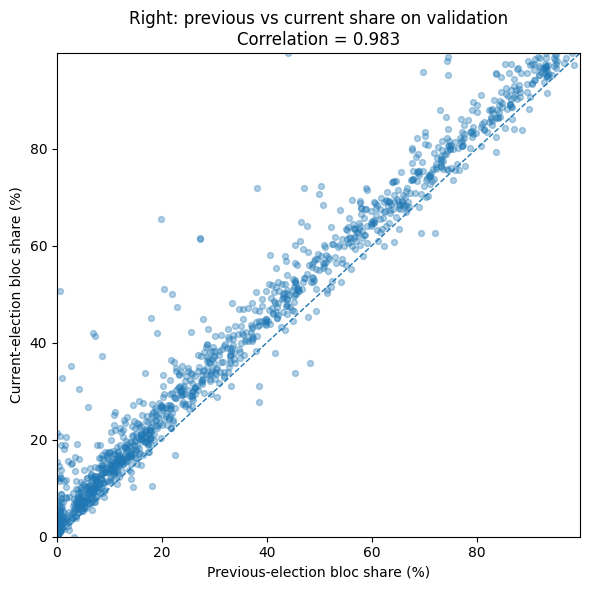

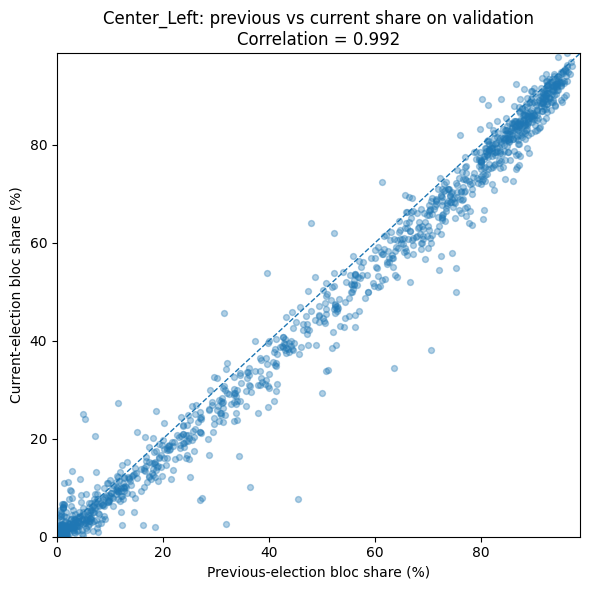

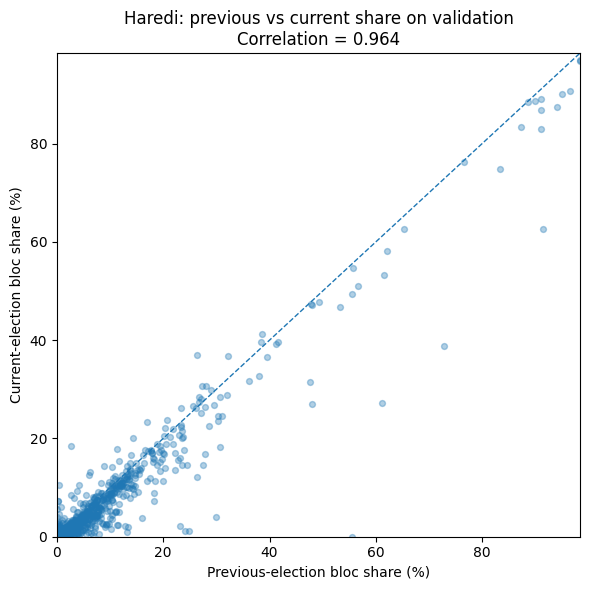

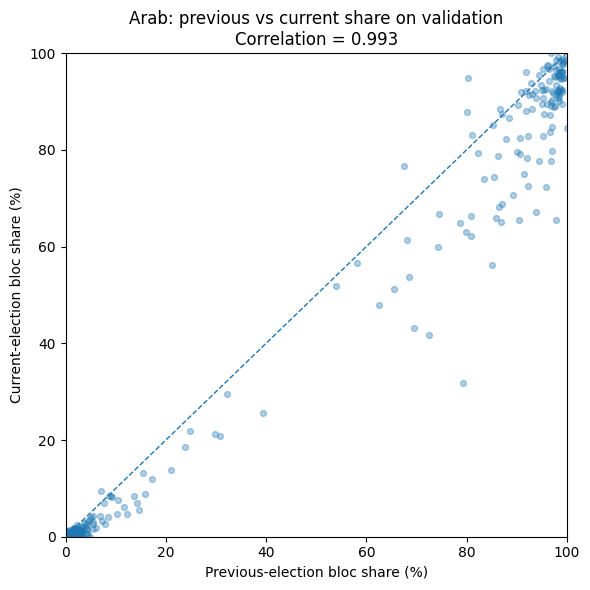

In [8]:

STABILITY_FIGURE_PATHS = {}

for bloc in MODELED_BLOCS:
    previous = validation_data[
        f"previous_{bloc}_pct"
    ]

    current = validation_data[
        f"current_{bloc}_pct"
    ]

    figure, axis = plt.subplots(
        figsize=(6, 6),
    )

    axis.scatter(
        previous,
        current,
        alpha=0.35,
        s=18,
    )

    limits = [
        min(previous.min(), current.min()),
        max(previous.max(), current.max()),
    ]

    axis.plot(
        limits,
        limits,
        linestyle="--",
        linewidth=1,
    )

    correlation = safe_correlation(
        previous,
        current,
    )

    axis.set_title(
        f"{bloc}: previous vs current share "
        f"on validation\nCorrelation = {correlation:.3f}"
    )

    axis.set_xlabel(
        "Previous-election bloc share (%)"
    )

    axis.set_ylabel(
        "Current-election bloc share (%)"
    )

    axis.set_xlim(limits)
    axis.set_ylim(limits)

    plt.tight_layout()

    figure_path = (
        FIGURES_DIR
        / f"validation_stability_{bloc.lower()}.png"
    )

    plt.savefig(
        figure_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    STABILITY_FIGURE_PATHS[bloc] = figure_path



## 7. Define baseline models

All fitted baseline parameters are learned from the two training transitions only.

### Baseline 1 — Global mean voting level

Predict every validation locality using the average current bloc composition in the training data.

### Baseline 2 — Locality-type mean voting level

Predict each validation locality using the average current bloc composition of its locality type in the training data.

This baseline directly tests the review comment that locality type alone may reveal most of the answer.

### Baseline 3 — Previous-election persistence

Predict that the validation locality repeats its previous-election composition.

### Baseline 4 — Global historical swing

Start with the previous election and add the average historical CLR change observed in training.

### Baseline 5 — Locality-type historical swing

Start with the previous election and add the average historical CLR change for the locality type observed in training.


In [9]:

CURRENT_PCT_COLUMNS = [
    f"current_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

PREVIOUS_PCT_COLUMNS = [
    f"previous_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

PREVIOUS_CLR_COLUMNS = [
    f"previous_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

DELTA_CLR_COLUMNS = [
    f"delta_clr_{bloc}"
    for bloc in MODELED_BLOCS
]


def close_percentages(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    values = np.clip(
        values,
        0,
        None,
    )

    row_sums = values.sum(
        axis=1,
        keepdims=True,
    )

    if np.any(row_sums <= 0):
        raise ValueError(
            "At least one predicted composition has a non-positive total."
        )

    return (
        values
        / row_sums
        * 100
    )


def inverse_clr(clr_values):
    clr_values = np.asarray(
        clr_values,
        dtype=float,
    )

    shifted = (
        clr_values
        - clr_values.max(
            axis=1,
            keepdims=True,
        )
    )

    exp_values = np.exp(shifted)

    return close_percentages(
        exp_values
    )


def predict_group_values(
    data,
    group_column,
    lookup_table,
    fallback_values,
):
    predictions = []

    for group_value in data[group_column]:
        if group_value in lookup_table.index:
            values = lookup_table.loc[
                group_value
            ].to_numpy(dtype=float)
        else:
            values = np.asarray(
                fallback_values,
                dtype=float,
            )

        predictions.append(values)

    return np.vstack(predictions)


In [10]:

# Baseline 1: global mean current composition.
global_mean_level = (
    train_data[
        CURRENT_PCT_COLUMNS
    ].mean().to_numpy()
)

global_mean_level_predictions = (
    np.tile(
        global_mean_level,
        (
            len(validation_data),
            1,
        ),
    )
)

global_mean_level_predictions = (
    close_percentages(
        global_mean_level_predictions
    )
)


# Baseline 2: locality-type mean current composition.
type_mean_level_lookup = (
    train_data.groupby(
        "locality_type",
        observed=False,
    )[CURRENT_PCT_COLUMNS]
    .mean()
)

type_mean_level_predictions = (
    predict_group_values(
        validation_data,
        "locality_type",
        type_mean_level_lookup,
        global_mean_level,
    )
)

type_mean_level_predictions = (
    close_percentages(
        type_mean_level_predictions
    )
)


# Baseline 3: previous-election persistence.
persistence_predictions = (
    validation_data[
        PREVIOUS_PCT_COLUMNS
    ].to_numpy(dtype=float)
)

persistence_predictions = (
    close_percentages(
        persistence_predictions
    )
)


# Baseline 4: global historical CLR swing.
global_mean_clr_swing = (
    train_data[
        DELTA_CLR_COLUMNS
    ].mean().to_numpy()
)

global_swing_clr_predictions = (
    validation_data[
        PREVIOUS_CLR_COLUMNS
    ].to_numpy(dtype=float)
    + global_mean_clr_swing
)

global_swing_predictions = inverse_clr(
    global_swing_clr_predictions
)


# Baseline 5: locality-type historical CLR swing.
type_mean_clr_swing_lookup = (
    train_data.groupby(
        "locality_type",
        observed=False,
    )[DELTA_CLR_COLUMNS]
    .mean()
)

type_swing_values = predict_group_values(
    validation_data,
    "locality_type",
    type_mean_clr_swing_lookup,
    global_mean_clr_swing,
)

type_swing_clr_predictions = (
    validation_data[
        PREVIOUS_CLR_COLUMNS
    ].to_numpy(dtype=float)
    + type_swing_values
)

type_swing_predictions = inverse_clr(
    type_swing_clr_predictions
)


BASELINE_PREDICTIONS = {
    "Global mean level": (
        global_mean_level_predictions
    ),
    "Locality-type mean level": (
        type_mean_level_predictions
    ),
    "Previous-election persistence": (
        persistence_predictions
    ),
    "Global historical CLR swing": (
        global_swing_predictions
    ),
    "Locality-type CLR swing": (
        type_swing_predictions
    ),
}


## 8. Evaluation functions

In [11]:

def evaluate_predictions(
    data,
    predictions,
    model_name,
):
    y_true = data[
        CURRENT_PCT_COLUMNS
    ].to_numpy(dtype=float)

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    if predictions.shape != y_true.shape:
        raise ValueError(
            f"{model_name}: prediction shape "
            f"{predictions.shape} does not match target shape "
            f"{y_true.shape}."
        )

    composition_error = np.abs(
        predictions.sum(axis=1)
        - 100
    ).max()

    if composition_error > 1e-6:
        raise ValueError(
            f"{model_name}: predictions do not sum to 100. "
            f"Maximum error: {composition_error}"
        )

    absolute_errors = np.abs(
        y_true
        - predictions
    )

    row_mae = absolute_errors.mean(
        axis=1
    )

    weights = data[
        "current_valid_votes"
    ].to_numpy(dtype=float)

    weighted_mae = np.average(
        row_mae,
        weights=weights,
    )

    r2_values = []

    for index, bloc in enumerate(
        MODELED_BLOCS
    ):
        r2_values.append(
            r2_score(
                y_true[:, index],
                predictions[:, index],
            )
        )

    overall = {
        "model": model_name,
        "rows": len(data),
        "mae": float(
            absolute_errors.mean()
        ),
        "median_row_mae": float(
            np.median(row_mae)
        ),
        "weighted_mae": float(
            weighted_mae
        ),
        "macro_r2": float(
            np.mean(r2_values)
        ),
        "max_prediction_sum_error": float(
            composition_error
        ),
    }

    by_bloc = []

    for index, bloc in enumerate(
        MODELED_BLOCS
    ):
        by_bloc.append({
            "model": model_name,
            "bloc": bloc,
            "rows": len(data),
            "mae": float(
                absolute_errors[
                    :,
                    index,
                ].mean()
            ),
            "median_absolute_error": float(
                np.median(
                    absolute_errors[
                        :,
                        index,
                    ]
                )
            ),
            "r2": float(
                r2_values[index]
            ),
        })

    return overall, by_bloc


def evaluate_by_group(
    data,
    predictions,
    model_name,
    group_column,
):
    rows = []

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    for group_value in sorted(
        data[group_column]
        .dropna()
        .unique()
        .tolist()
    ):
        mask = (
            data[group_column]
            .eq(group_value)
            .to_numpy()
        )

        group_data = data.loc[
            mask
        ]

        group_predictions = (
            predictions[mask]
        )

        overall, _ = evaluate_predictions(
            group_data,
            group_predictions,
            model_name,
        )

        rows.append({
            "model": model_name,
            "group_variable": group_column,
            "group": str(group_value),
            **{
                key: value
                for key, value
                in overall.items()
                if key != "model"
            },
        })

    return rows


## 9. Compare baselines on the validation transition

In [12]:

overall_rows = []
bloc_rows = []
group_rows = []
locality_type_rows = []

for model_name, predictions in (
    BASELINE_PREDICTIONS.items()
):
    overall, by_bloc = (
        evaluate_predictions(
            validation_data,
            predictions,
            model_name,
        )
    )

    overall_rows.append(overall)
    bloc_rows.extend(by_bloc)

    group_rows.extend(
        evaluate_by_group(
            validation_data,
            predictions,
            model_name,
            "analysis_group",
        )
    )

    locality_type_rows.extend(
        evaluate_by_group(
            validation_data,
            predictions,
            model_name,
            "locality_type",
        )
    )

baseline_comparison = pd.DataFrame(
    overall_rows
).sort_values(
    "mae"
).reset_index(drop=True)

baseline_comparison_by_bloc = (
    pd.DataFrame(bloc_rows)
    .sort_values(
        ["bloc", "mae"]
    )
    .reset_index(drop=True)
)

baseline_comparison_by_group = (
    pd.DataFrame(group_rows)
    .sort_values(
        ["group", "mae"]
    )
    .reset_index(drop=True)
)

baseline_comparison_by_locality_type = (
    pd.DataFrame(locality_type_rows)
    .sort_values(
        ["group", "mae"]
    )
    .reset_index(drop=True)
)

persistence_mae = float(
    baseline_comparison.loc[
        baseline_comparison["model"].eq(
            "Previous-election persistence"
        ),
        "mae",
    ].iloc[0]
)

baseline_comparison[
    "absolute_mae_improvement_vs_persistence"
] = (
    persistence_mae
    - baseline_comparison["mae"]
)

baseline_comparison[
    "relative_mae_improvement_vs_persistence_pct"
] = np.where(
    persistence_mae > 0,
    baseline_comparison[
        "absolute_mae_improvement_vs_persistence"
    ]
    / persistence_mae
    * 100,
    np.nan,
)

baseline_comparison


,model,rows,mae,median_row_mae,weighted_mae,macro_r2,max_prediction_sum_error,absolute_mae_improvement_vs_persistence,relative_mae_improvement_vs_persistence_pct
0,Previous-election persistence,1212,3.082348,2.430337,2.398171,0.946765,2.842171e-14,0.000000,0.000000
1,Global historical CLR swing,1212,4.622728,3.932465,5.398533,0.862449,2.842171e-14,-1.540379,-49.974215
2,Locality-type CLR swing,1212,4.623373,3.760752,4.110192,0.861530,4.263256e-14,-1.541024,-49.995139
3,Locality-type mean level,1212,13.825391,11.653142,11.163454,0.305152,0.000000e+00,-10.743042,-348.534325
4,Global mean level,1212,19.633470,18.015585,15.218501,-0.017981,2.842171e-14,-16.551122,-536.964659



A positive improvement value means the baseline performs better than previous-election persistence. A negative value means it performs worse.


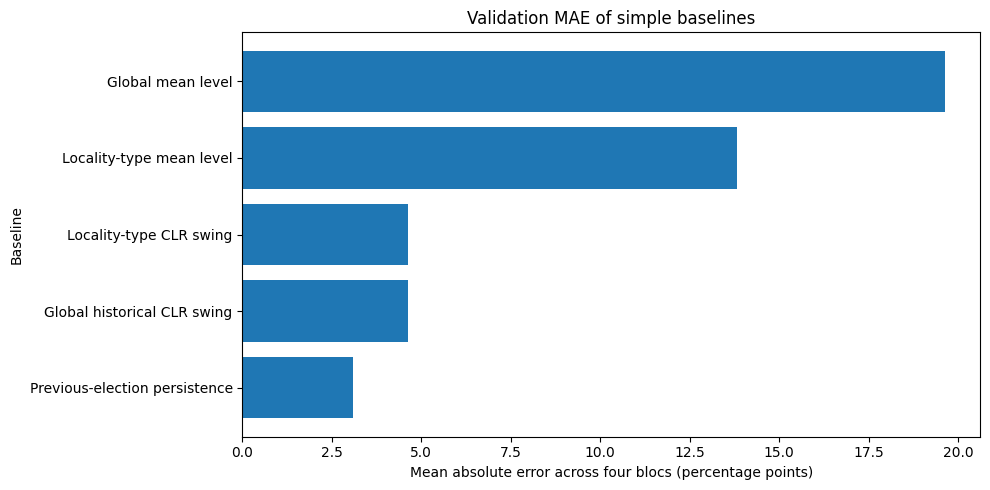

Figure saved to: /content/Election_Bloc_Prediction_Project/reports/figures/baseline_validation_comparison.png


In [13]:

figure, axis = plt.subplots(
    figsize=(10, 5),
)

plot_data = baseline_comparison.sort_values(
    "mae",
    ascending=True,
)

axis.barh(
    plot_data["model"],
    plot_data["mae"],
)

axis.set_title(
    "Validation MAE of simple baselines"
)

axis.set_xlabel(
    "Mean absolute error across four blocs "
    "(percentage points)"
)

axis.set_ylabel("Baseline")

plt.tight_layout()

BASELINE_COMPARISON_FIGURE_PATH = (
    FIGURES_DIR
    / "baseline_validation_comparison.png"
)

plt.savefig(
    BASELINE_COMPARISON_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    BASELINE_COMPARISON_FIGURE_PATH,
)


## 10. Inspect performance by bloc and population group

In [14]:

baseline_comparison_by_bloc


,model,bloc,rows,mae,median_absolute_error,r2
0,Previous-election persistence,Arab,1212,1.265848,0.217156,0.978360
1,Global historical CLR swing,Arab,1212,2.558379,0.633682,0.944069
2,Locality-type CLR swing,Arab,1212,2.678994,0.633841,0.943000
3,Locality-type mean level,Arab,1212,7.202816,0.634805,0.582221
4,Global mean level,Arab,1212,16.413438,9.851808,-0.000399
5,Locality-type CLR swing,Center_Left,1212,3.846526,2.651122,0.972390
6,Global historical CLR swing,Center_Left,1212,3.874528,2.837285,0.972948
7,Previous-election persistence,Center_Left,1212,3.954453,3.018053,0.972787
8,Locality-type mean level,Center_Left,1212,22.642940,20.510003,0.317773
9,Global mean level,Center_Left,1212,30.421089,33.016716,-0.020511


In [15]:

baseline_comparison_by_group


,model,group_variable,group,rows,mae,median_row_mae,weighted_mae,macro_r2,max_prediction_sum_error
0,Previous-election persistence,analysis_group,Arab/Non-Jewish,101,5.296837,3.772768,3.692116,0.683430,1.421085e-14
1,Global historical CLR swing,analysis_group,Arab/Non-Jewish,101,6.741404,4.289250,5.115458,0.628612,2.842171e-14
2,Locality-type CLR swing,analysis_group,Arab/Non-Jewish,101,7.004695,4.410254,5.341501,0.579191,2.842171e-14
3,Locality-type mean level,analysis_group,Arab/Non-Jewish,101,12.755798,9.015807,10.667661,-0.072020,0.000000e+00
4,Global mean level,analysis_group,Arab/Non-Jewish,101,33.535204,39.569244,36.458624,-2.724336,2.842171e-14
5,Previous-election persistence,analysis_group,Non-Arab,1111,2.881031,2.373222,2.276904,0.947297,2.842171e-14
6,Locality-type CLR swing,analysis_group,Non-Arab,1111,4.406889,3.740101,3.994796,0.857495,4.263256e-14
7,Global historical CLR swing,analysis_group,Non-Arab,1111,4.430121,3.876821,5.425062,0.856228,2.842171e-14
8,Locality-type mean level,analysis_group,Non-Arab,1111,13.922626,12.468197,11.209919,0.168350,0.000000e+00
9,Global mean level,analysis_group,Non-Arab,1111,18.369676,17.379264,13.227907,-0.061982,2.842171e-14



The subgroup table is especially important because a high overall R² can be inflated by large differences between Arab and non-Arab localities.

The key comparison is therefore whether the baselines remain useful **within** each broad group.


## 11. Where is meaningful change available to model?

In [16]:

validation_delta_columns = [
    f"delta_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

validation_change_analysis = (
    validation_data[
        [
            "locality_symbol",
            "locality_name",
            "locality_type",
            "analysis_group",
            "transition_id",
            *validation_delta_columns,
        ]
    ]
    .copy()
)

validation_change_analysis[
    "mean_absolute_bloc_change"
] = (
    validation_change_analysis[
        validation_delta_columns
    ]
    .abs()
    .mean(axis=1)
)

validation_change_analysis[
    "maximum_absolute_bloc_change"
] = (
    validation_change_analysis[
        validation_delta_columns
    ]
    .abs()
    .max(axis=1)
)

largest_validation_changes = (
    validation_change_analysis
    .sort_values(
        "mean_absolute_bloc_change",
        ascending=False,
    )
    .head(50)
    .reset_index(drop=True)
)

largest_validation_changes.head(20)


,locality_symbol,locality_name,locality_type,analysis_group,transition_id,delta_Right_pct,delta_Center_Left_pct,delta_Haredi_pct,delta_Arab_pct,mean_absolute_bloc_change,maximum_absolute_bloc_change
0,1366,נווה,Moshavim,Non-Arab,K23_to_K24,55.530240,-0.015534,-55.514706,0.000000,27.765120,55.530240
1,523,ניין,Arab/Non-Jewish,Arab/Non-Jewish,K23_to_K24,50.059517,-19.354605,0.000000,-30.704912,25.029758,50.059517
2,1346,תראבין אצאנעישוב,other,Non-Arab,K23_to_K24,45.630119,1.067514,0.823045,-47.520678,23.760339,47.520678
3,921,שער מנשה,other,Non-Arab,K23_to_K24,34.265734,-37.762238,3.496503,0.000000,18.881119,37.762238
4,1246,עראמשה,other,Non-Arab,K23_to_K24,35.288925,-5.898970,-3.125000,-26.264955,17.644462,35.288925
5,212,בית צבי,other,Non-Arab,K23_to_K24,34.017595,0.000000,-34.017595,0.000000,17.008798,34.017595
6,1170,סייד שבט,other,Non-Arab,K23_to_K24,34.005078,-5.055538,0.000000,-28.949540,17.002539,34.005078
7,696,כפר חבד,Cities,Non-Arab,K23_to_K24,33.858705,0.047515,-33.871454,-0.034767,16.953110,33.871454
8,4203,מסעדה,Arab/Non-Jewish,Arab/Non-Jewish,K23_to_K24,27.121705,-32.484651,5.886602,-0.523655,16.504153,32.484651
9,1359,אל סייד,Arab/Non-Jewish,Arab/Non-Jewish,K23_to_K24,32.472785,-13.801031,-0.095880,-18.575873,16.236392,32.472785



These rows are not yet model anomalies. They are simply the largest observed changes in the validation transition and help identify where the revised modeling task contains signal beyond stable voting levels.


## 12. Automated factual summary

In [17]:

best_baseline_row = (
    baseline_comparison
    .sort_values("mae")
    .iloc[0]
)

type_only_row = (
    baseline_comparison.loc[
        baseline_comparison["model"].eq(
            "Locality-type mean level"
        )
    ]
    .iloc[0]
)

persistence_row = (
    baseline_comparison.loc[
        baseline_comparison["model"].eq(
            "Previous-election persistence"
        )
    ]
    .iloc[0]
)

summary_table = pd.DataFrame([
    {
        "finding": "Best validation baseline",
        "value": best_baseline_row["model"],
    },
    {
        "finding": "Best validation MAE",
        "value": float(
            best_baseline_row["mae"]
        ),
    },
    {
        "finding": "Persistence validation MAE",
        "value": float(
            persistence_row["mae"]
        ),
    },
    {
        "finding": "Locality-type-only validation MAE",
        "value": float(
            type_only_row["mae"]
        ),
    },
    {
        "finding": "Does locality type alone beat persistence?",
        "value": bool(
            type_only_row["mae"]
            < persistence_row["mae"]
        ),
    },
    {
        "finding": "Final test rows kept locked",
        "value": int(
            len(final_test_data)
        ),
    },
])

summary_table


,finding,value
0,Best validation baseline,Previous-election persistence
1,Best validation MAE,3.082348
2,Persistence validation MAE,3.082348
3,Locality-type-only validation MAE,13.825391
4,Does locality type alone beat persistence?,False
5,Final test rows kept locked,1213



## 13. Save outputs

The enriched panel is saved for later feature engineering.

The final-test rows remain in the file because later notebooks need them, but the split variables recorded in this notebook must continue to be respected.


In [18]:

ENRICHED_PANEL_PATH = (
    INTERIM_DIR
    / "election_transition_panel_with_locality_type.csv"
)

LOCALITY_TYPE_MERGE_AUDIT_PATH = (
    TABLES_DIR
    / "locality_type_merge_audit.csv"
)

SPLIT_SUMMARY_PATH = (
    TABLES_DIR
    / "experimental_split_summary.csv"
)

STABILITY_TRANSITION_PATH = (
    TABLES_DIR
    / "stability_by_transition_and_bloc.csv"
)

STABILITY_GROUP_PATH = (
    TABLES_DIR
    / "stability_by_group_and_bloc.csv"
)

BASELINE_COMPARISON_PATH = (
    TABLES_DIR
    / "baseline_comparison_validation.csv"
)

BASELINE_BY_BLOC_PATH = (
    TABLES_DIR
    / "baseline_comparison_by_bloc_validation.csv"
)

BASELINE_BY_GROUP_PATH = (
    TABLES_DIR
    / "baseline_comparison_by_group_validation.csv"
)

BASELINE_BY_TYPE_PATH = (
    TABLES_DIR
    / "baseline_comparison_by_locality_type_validation.csv"
)

LARGEST_CHANGES_PATH = (
    TABLES_DIR
    / "largest_validation_changes.csv"
)

NOTEBOOK_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_03_summary.json"
)

panel_with_type.to_csv(
    ENRICHED_PANEL_PATH,
    index=False,
    encoding="utf-8-sig",
)

locality_type_merge_audit.to_csv(
    LOCALITY_TYPE_MERGE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

split_summary.to_csv(
    SPLIT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

stability_by_transition_and_bloc.to_csv(
    STABILITY_TRANSITION_PATH,
    index=False,
    encoding="utf-8-sig",
)

stability_by_group_and_bloc.to_csv(
    STABILITY_GROUP_PATH,
    index=False,
    encoding="utf-8-sig",
)

baseline_comparison.to_csv(
    BASELINE_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

baseline_comparison_by_bloc.to_csv(
    BASELINE_BY_BLOC_PATH,
    index=False,
    encoding="utf-8-sig",
)

baseline_comparison_by_group.to_csv(
    BASELINE_BY_GROUP_PATH,
    index=False,
    encoding="utf-8-sig",
)

baseline_comparison_by_locality_type.to_csv(
    BASELINE_BY_TYPE_PATH,
    index=False,
    encoding="utf-8-sig",
)

largest_validation_changes.to_csv(
    LARGEST_CHANGES_PATH,
    index=False,
    encoding="utf-8-sig",
)

summary = {
    "notebook": "03_eda_and_baselines",
    "experimental_split": {
        "train_transitions": TRAIN_TRANSITIONS,
        "validation_transition": VALIDATION_TRANSITION,
        "final_test_transition": FINAL_TEST_TRANSITION,
        "train_rows": int(len(train_data)),
        "validation_rows": int(
            len(validation_data)
        ),
        "final_test_rows_locked": int(
            len(final_test_data)
        ),
    },
    "locality_type_merge": {
        "rows_without_type_before_fallback": (
            missing_type_rows
        ),
        "fallback_label": "Unknown",
    },
    "validation_results": {
        "best_baseline": str(
            best_baseline_row["model"]
        ),
        "best_mae": float(
            best_baseline_row["mae"]
        ),
        "persistence_mae": float(
            persistence_row["mae"]
        ),
        "locality_type_only_mae": float(
            type_only_row["mae"]
        ),
        "locality_type_only_beats_persistence": bool(
            type_only_row["mae"]
            < persistence_row["mae"]
        ),
    },
    "final_test_policy": (
        "K24_to_K25 was excluded from all baseline "
        "fitting, comparisons, stability statistics "
        "and locality inspection in this notebook."
    ),
    "outputs": {
        "enriched_panel": str(
            ENRICHED_PANEL_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "baseline_comparison": str(
            BASELINE_COMPARISON_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "baseline_by_bloc": str(
            BASELINE_BY_BLOC_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "baseline_by_group": str(
            BASELINE_BY_GROUP_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "stability_by_transition": str(
            STABILITY_TRANSITION_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "largest_validation_changes": str(
            LARGEST_CHANGES_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "baseline_figure": str(
            BASELINE_COMPARISON_FIGURE_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "stability_figures": {
            bloc: str(
                path.relative_to(
                    REPO_ROOT
                )
            )
            for bloc, path
            in STABILITY_FIGURE_PATHS.items()
        },
    },
}

with NOTEBOOK_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:")
for path in [
    ENRICHED_PANEL_PATH,
    LOCALITY_TYPE_MERGE_AUDIT_PATH,
    SPLIT_SUMMARY_PATH,
    STABILITY_TRANSITION_PATH,
    STABILITY_GROUP_PATH,
    BASELINE_COMPARISON_PATH,
    BASELINE_BY_BLOC_PATH,
    BASELINE_BY_GROUP_PATH,
    BASELINE_BY_TYPE_PATH,
    LARGEST_CHANGES_PATH,
    BASELINE_COMPARISON_FIGURE_PATH,
    *STABILITY_FIGURE_PATHS.values(),
    NOTEBOOK_SUMMARY_PATH,
]:
    print("-", path)


Saved:
- /content/Election_Bloc_Prediction_Project/data/interim/election_transition_panel_with_locality_type.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/locality_type_merge_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/experimental_split_summary.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/stability_by_transition_and_bloc.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/stability_by_group_and_bloc.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/baseline_comparison_validation.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/baseline_comparison_by_bloc_validation.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/baseline_comparison_by_group_validation.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/baseline_comparison_by_locality_type_validation.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/largest_validation_changes.csv
- /content/Election_B


## Notebook 03 completion checklist

This notebook is complete when:

- The locality-type merge is audited.
- K24→K25 remains locked and excluded from analysis.
- Voting stability is quantified on development transitions.
- The persistence baseline is evaluated on K23→K24.
- Locality-type-only prediction is compared directly with persistence.
- Historical-swing baselines are fitted on earlier transitions only.
- Results are reported by bloc.
- Results are reported separately for Arab/non-Jewish and non-Arab localities.
- Large validation changes are documented without calling them anomalies.
- All tables, figures and summaries are saved successfully.

The next notebook is:

> `04_feature_engineering.ipynb`

It will load the 2019–2023 demographic, education, income and welfare data, harmonize their schemas, create time-aligned level and change features, and audit which variables are actually available for the 2023 scenario forecast.
